# Maps of the difference of probability between BBM and aEVP rheologies

This notebook aims at creating some illustrative maps to complement the notebook Probability_maps_defo.ipynb. The maps created here are the difference between the two rheologies – BBM and aEVP – of the probability of having a deformation superior to the 95% percentile at least once a day.

In [1]:
#Libraries needed

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from cmocean import cm

### Loading the data

In [2]:
#Some useful variables for the loading

##some useful paths
path_store_NANUK4="/lustre/fsstor/projects/rech/cli/commun/NANUK4/" #where the outputs of the simulations are
path_proba="/lustre/fsn1/projects/rech/cli/udf71br/data_proba_maps/" #where the values of probability are stored

#the experiments and period of interest
exp_interest_BBM="EBLKBBM050" ; exp_interest_EVP="EBLKEVP050"
period_interest="19970307_19970316"

print(exp_interest_BBM,exp_interest_EVP,period_interest)

EBLKBBM050 EBLKEVP050 19970307_19970316


In [3]:
#Loading the probability maps of having defo > 95% percentile at least once over a day

proba_maps=[] #the first element will be the probability map of BBM and the second of aEVP
proba_maps.append(xr.open_dataset(path_proba+"data_proba_defo_occur_day_"+exp_interest_BBM+"_"+period_interest+".nc"))
proba_maps.append(xr.open_dataset(path_proba+"data_proba_defo_occur_day_"+exp_interest_EVP+"_"+period_interest+".nc"))

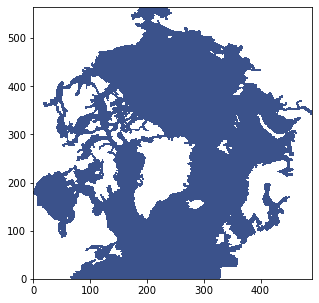

In [4]:
#Loading some masks

dat_masks=xr.open_dataset(path_store_NANUK4+"NANUK4.L31-I/mesh_mask_NANUK4_L31_4.2_1stLev.nc",decode_times=True) #configuration masks

##Visualisation of the configuration tmask

fig=plt.figure(figsize=(5,5))
plt.contourf(dat_masks.tmask[0,0,:,:].where(dat_masks.tmask[0,0,:,:]>0))
plt.show()

In [5]:
#Saving a time variable

list_days=proba_maps[0].day
print(list_days.values)

[ 1  2  3  4  5  6  7  8  9 10]


### Probability difference maps

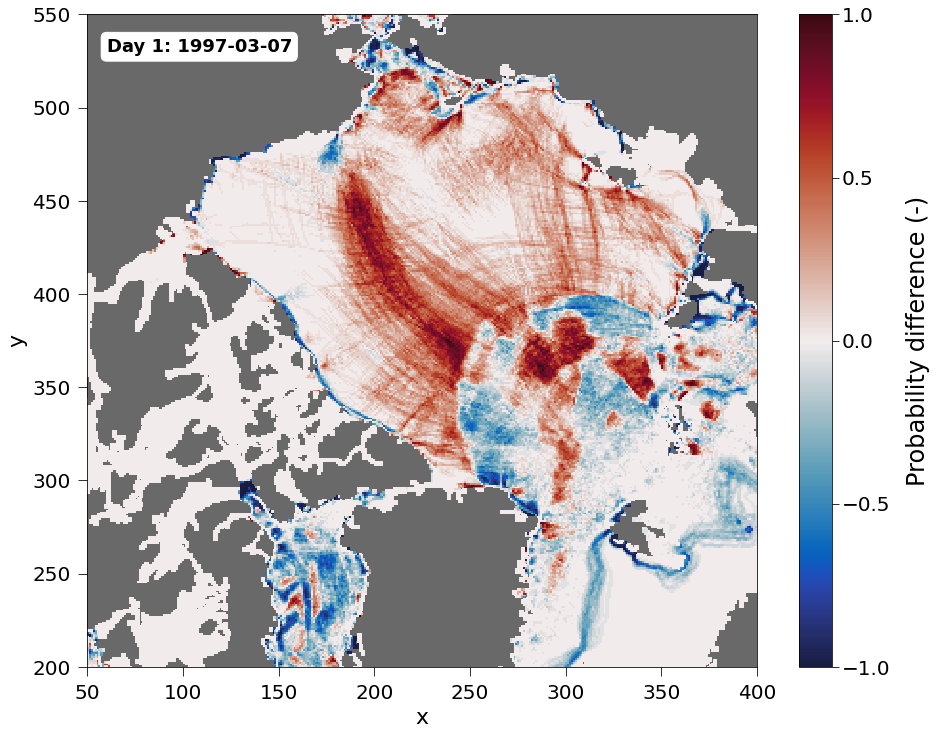

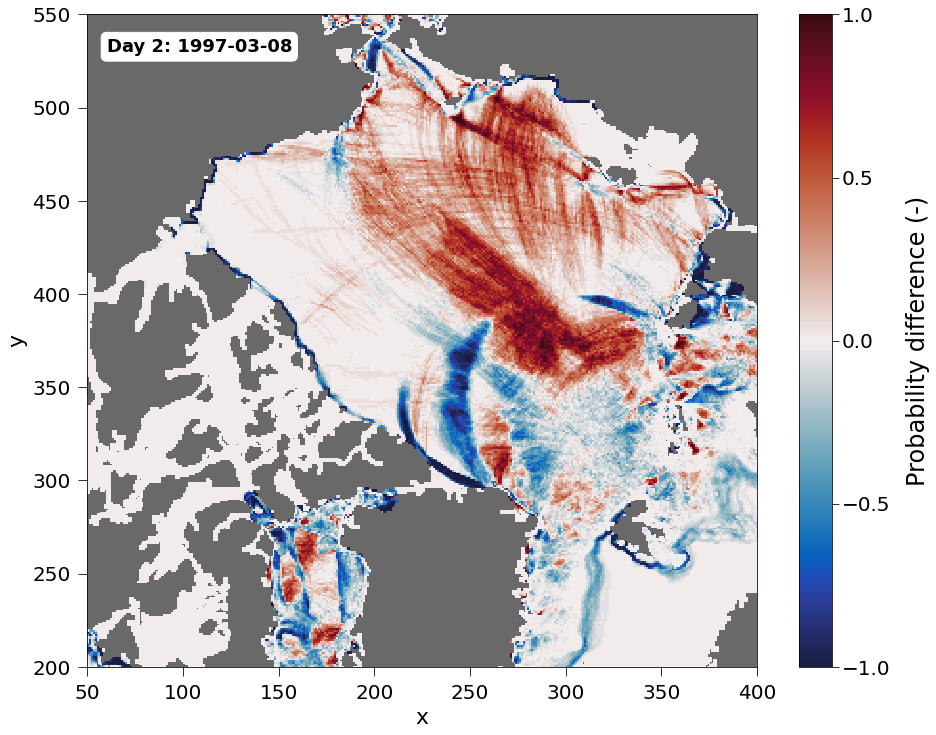

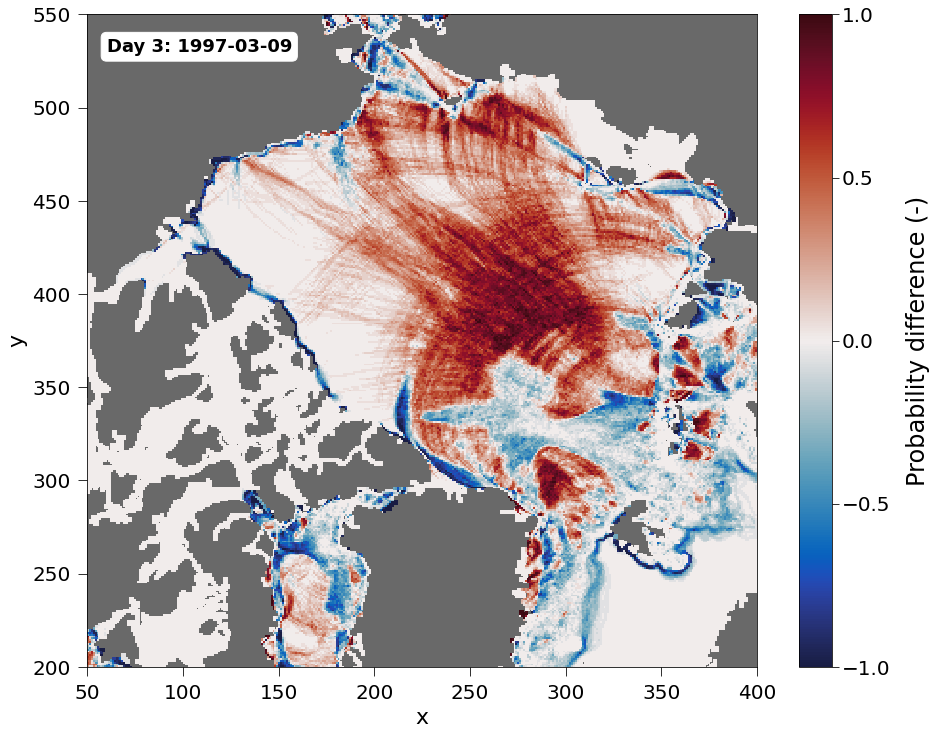

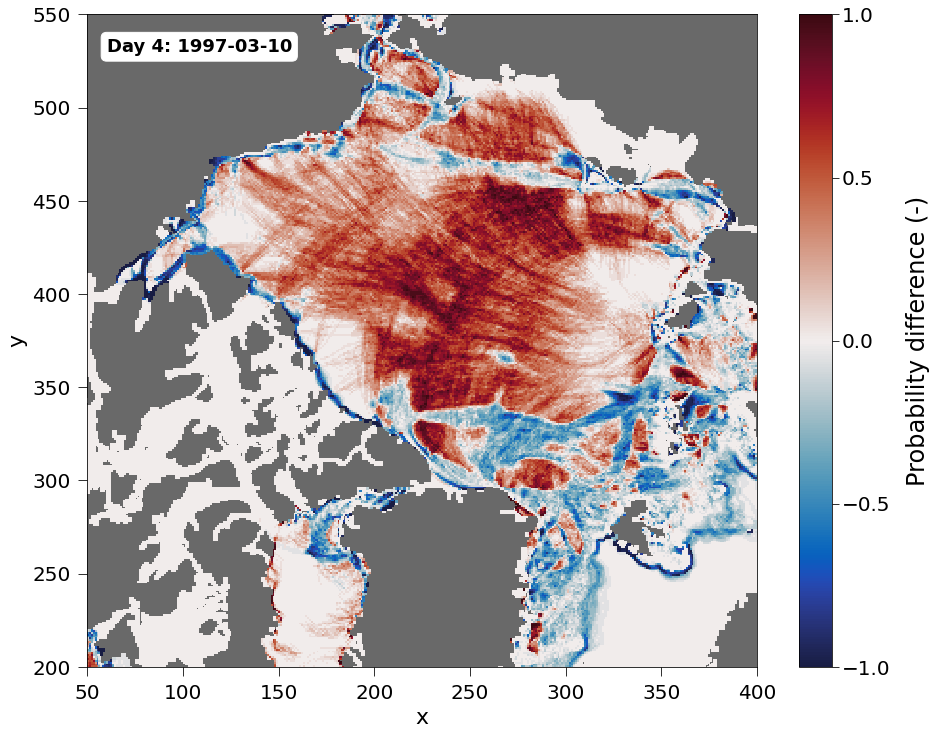

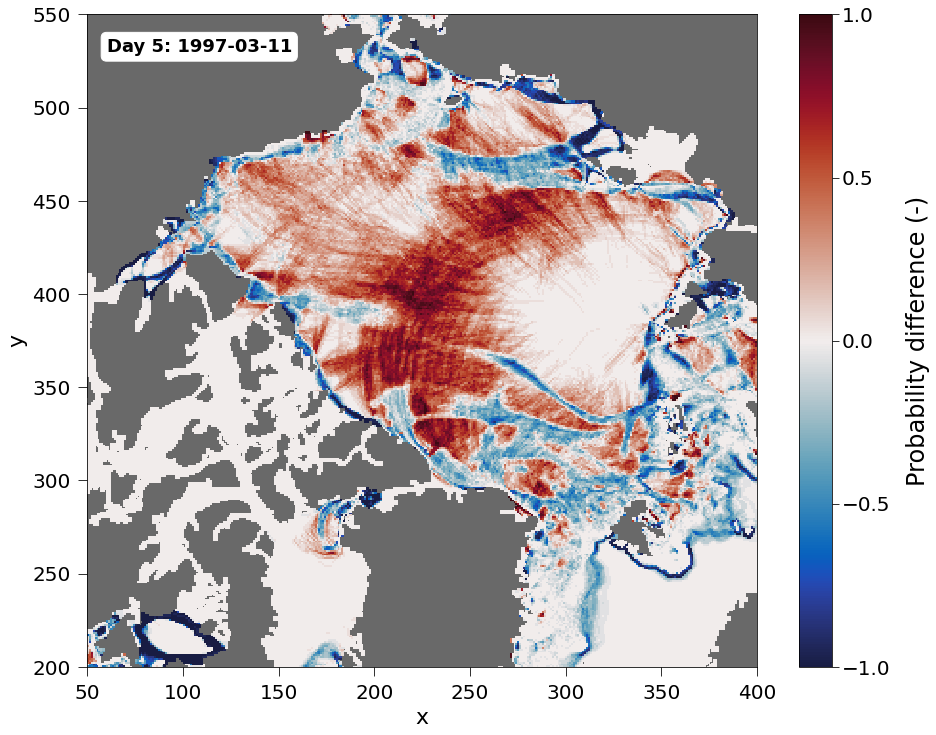

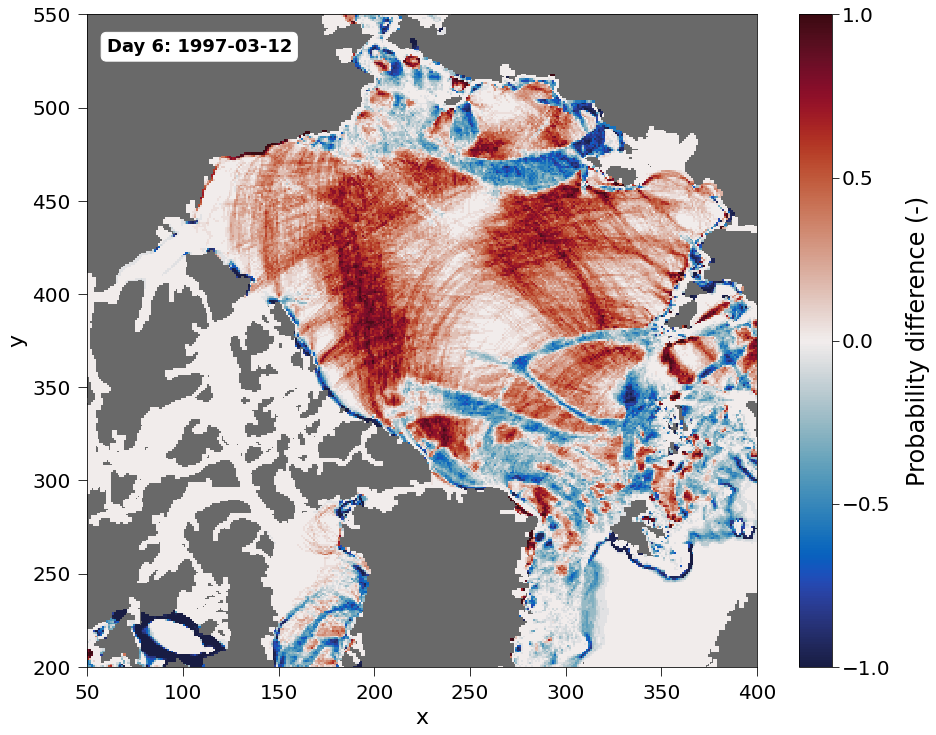

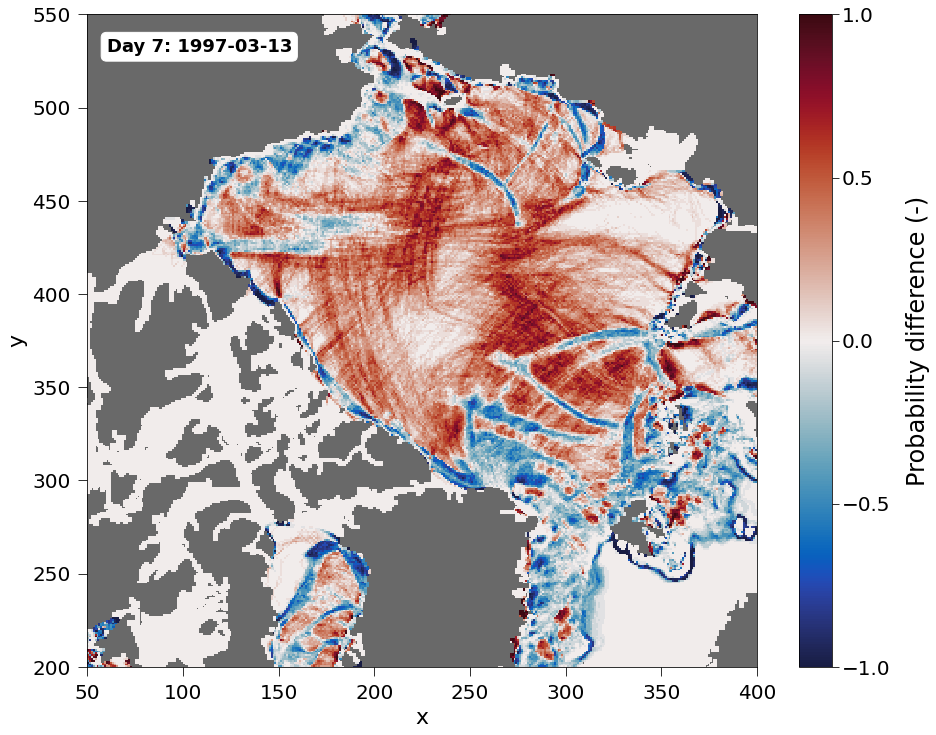

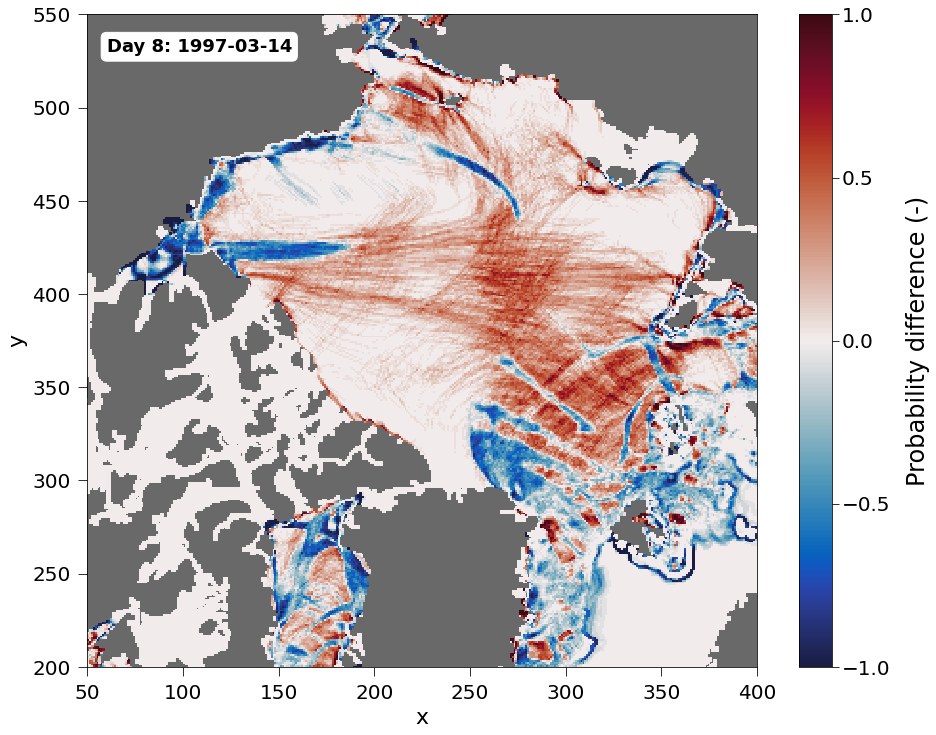

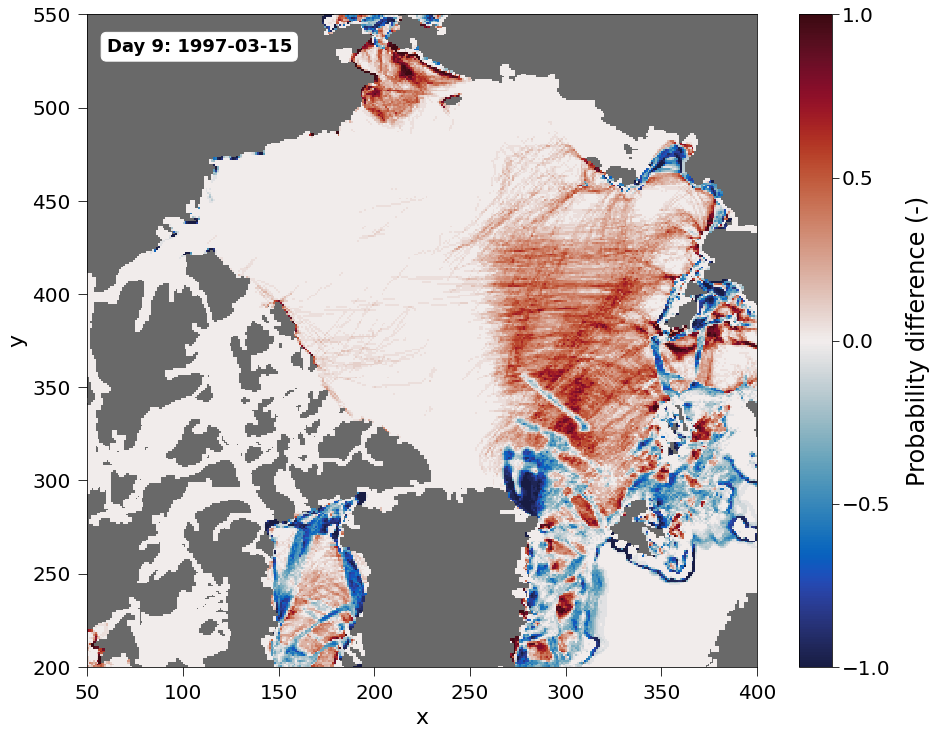

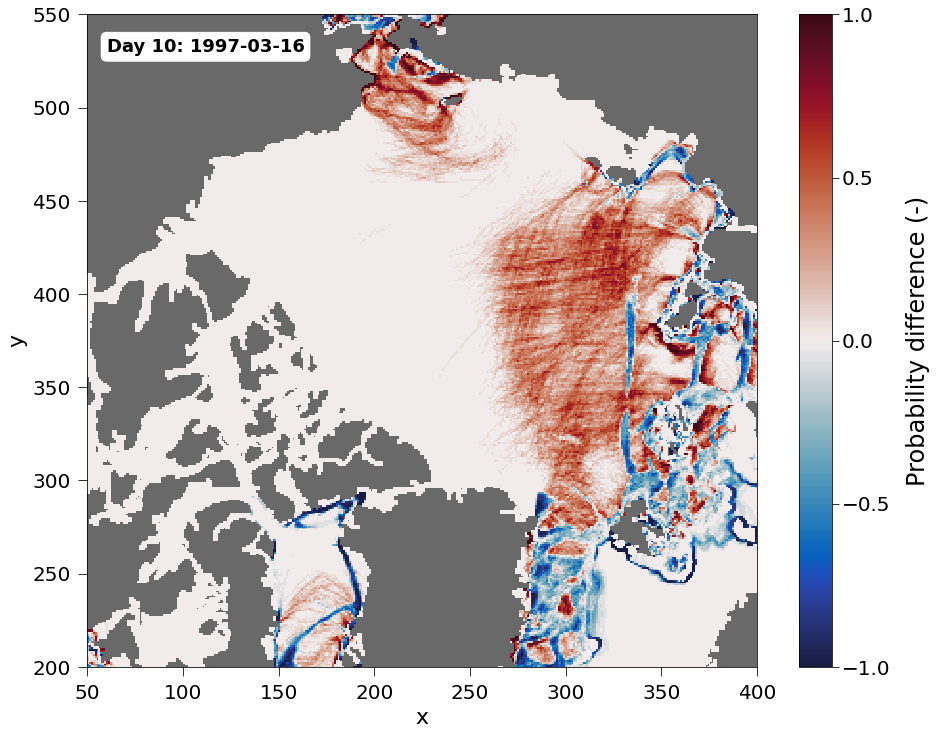

In [6]:
#Figures of the difference between the probability of having a deformation > 95% percentile at least once a day for BBM and aEVP rheology

##Instants of interest
t_interest=np.linspace(0,len(list_days)-1,len(list_days)).astype(np.int64)

for it in t_interest:#iteration over the instants that interest us

    ##Creation of the figure
    fig,ax=plt.subplots(1,1,figsize=(15,12))

    ##Plot the difference of the probability maps
    cf=ax.pcolormesh((proba_maps[0].proba_occurence_defo_day[it,:,:]-proba_maps[1].proba_occurence_defo_day[it,:,:]).where(dat_masks.tmask[0,0,:,:]>0),cmap=cm.balance,vmin=-1,vmax=1)

    ##Set up the colorbar
    cb=plt.colorbar(cf,ticks=[-1,-0.5,0,0.5,1],orientation="vertical",pad=0.05)
    cb.set_label('Probability difference (-)',color="black",fontsize=24,labelpad=15)
    cb.ax.tick_params(color="black",labelcolor="black",labelsize=20,length=7)

    ##Some informative texts
    ax.text(60, 530,"Day "+str(list_days[it].values)+": "+period_interest[:4]+"-"+period_interest[4:6]+"-"+str(int(period_interest[6:8])+it).zfill(2),\
            fontsize=18,fontweight="bold",color="black",bbox=dict(facecolor='white', edgecolor='white', boxstyle='round'))
    
    ##Set up the background
    ax.set_facecolor("dimgrey")
    
    ##Set up the axes
    ax.tick_params("both",labelsize=20,length=9,pad=8)
    ax.set_xlim(50,400) ; ax.set_ylim(200,550)
    ax.set_xlabel("x",fontsize=22,labelpad=5) ; ax.set_ylabel("y",fontsize=22,labelpad=5)

    plt.show()
    ##Save the figure (change the path if needed)
    #print("/lustre/fsn1/projects/rech/cli/udf71br/figures_animations_maps_proba/Illu_diff_proba_sup_sidefo_"+exp_interest_BBM+"-"+exp_interest_EVP+"_"+period_interest+"_day_"+str(list_days[it].values).zfill(2)+".png")
    #fig.savefig("/lustre/fsn1/projects/rech/cli/udf71br/figures_animations_maps_proba/Illu_diff_proba_sup_sidefo_"+exp_interest_BBM+"-"+exp_interest_EVP+"_"+period_interest+"_day_"+str(list_days[it].values).zfill(2)+".png",\
    #        facecolor="white",edgecolor="none",bbox_inches="tight")
    plt.close(fig)